In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.converters import circuit_to_dag,dag_to_circuit

import sys
sys.path.append("../")
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
import testing_scripts.graphs_utils as graphs_utils 
from testing_scripts.qaoa_utils import QAOASolver
import red_qaoa.red_qaoa as red_qaoa

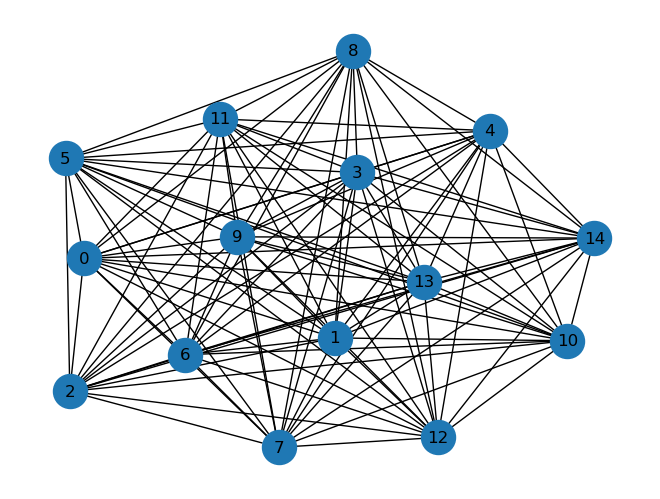

In [2]:
n = 15
k=3

# G = graphs_utils.generate_random_erdos_renyi_graph(num_nodes=n, probability=0.5, weighted=False,seed=1)
G=graphs_utils.generate_random_complete_graph(num_vertices=n, weighted=False, seed=2)
# G = graphs_utils.generate_random_ego_graph(num_vertices=n,weighted=False,seed=2)
# G = graphs_utils.generate_random_erdos_renyi_graph(num_nodes=n,probability=0.4,weighted=False,seed=4)



draw_graph(G, node_size=600, with_labels=True)

In [3]:
#The reduced rustworkx graph
nx_graph = graphs_utils.rustworkx_to_networkx(G)
red_nx_graph = red_qaoa.red_qaoa_exe(nx_graph)
red_G = graphs_utils.networkx_to_rustworkx(red_nx_graph)

In [4]:
max_cut_paulis = graphs_utils.build_max_cut_paulis(red_G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIZZ', 'IIIIIIIIIZIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIIZ', 'IIIIIIZIIIIZ', 'IIIIIZIIIIIZ', 'IIIIZIIIIIIZ', 'IIIZIIIIIIIZ', 'IIZIIIIIIIIZ', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIIZ', 'IIIIIIIIIZZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IIIIZIIIIIZI', 'IIIZIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IIIIZIIIIZII', 'IIIZIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IIIIZIIIZIII', 'IIIZIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IIIIZIIZIIII', 'IIIZIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIIZZIIIII', 'IIIIZIZIIIII', 'IIIZIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZIIIII', 'ZIIIIIZIIIII', 'IIIIZZIIIIII', 'IIIZIZIIIIII', 'IIZIIZIIIIII', 'IZIIIZIIIIII', 'ZIIIIZIIIIII', 'IIIZZIIIIIII', 'IIZIZIIIIIII', 'IZIIZIIIIIII', 'ZIIIZIIIIIII'

In [5]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [6]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
red_solver = QAOASolver(cost_hamiltonian,circuit.decompose().decompose(),sim_device="CPU")
red_solver.vanilla = True

In [7]:
x0 = np.random.rand(reps * 2) * np.pi
res,obj_values=red_solver.run_qaoa(x0)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

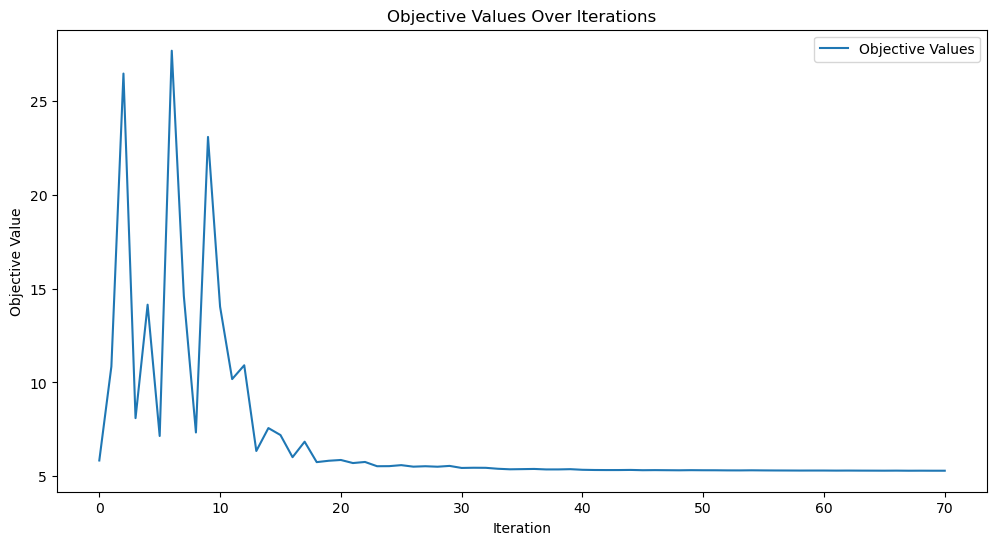

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()

In [9]:
best_red_params = res.x
res.fun

np.float64(5.294293838620761)

In [10]:
# Evaluated on Original Graph
max_cut_paulis = graphs_utils.build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIZIZ', 'IIIIIIIIIIIZIIZ', 'IIIIIIIIIIZIIIZ', 'IIIIIIIIIZIIIIZ', 'IIIIIIIIZIIIIIZ', 'IIIIIIIZIIIIIIZ', 'IIIIIIZIIIIIIIZ', 'IIIIIZIIIIIIIIZ', 'IIIIZIIIIIIIIIZ', 'IIIZIIIIIIIIIIZ', 'IIZIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIZZI', 'IIIIIIIIIIIZIZI', 'IIIIIIIIIIZIIZI', 'IIIIIIIIIZIIIZI', 'IIIIIIIIZIIIIZI', 'IIIIIIIZIIIIIZI', 'IIIIIIZIIIIIIZI', 'IIIIIZIIIIIIIZI', 'IIIIZIIIIIIIIZI', 'IIIZIIIIIIIIIZI', 'IIZIIIIIIIIIIZI', 'IZIIIIIIIIIIIZI', 'ZIIIIIIIIIIIIZI', 'IIIIIIIIIIIZZII', 'IIIIIIIIIIZIZII', 'IIIIIIIIIZIIZII', 'IIIIIIIIZIIIZII', 'IIIIIIIZIIIIZII', 'IIIIIIZIIIIIZII', 'IIIIIZIIIIIIZII', 'IIIIZIIIIIIIZII', 'IIIZIIIIIIIIZII', 'IIZIIIIIIIIIZII', 'IZIIIIIIIIIIZII', 'ZIIIIIIIIIIIZII', 'IIIIIIIIIIZZIII', 'IIIIIIIIIZIZIII', 'IIIIIIIIZIIZIII', 'IIIIIIIZIIIZIII', 'IIIIIIZIIIIZIII', 'IIIIIZIIIIIZIII', 'IIIIZIIIIIIZIII', 'IIIZIIIIIIIZIII', 'IIZIIIIIIIIZIII', 'IZIIIIIIIIIZIII', 'ZIIIIIIIIIIZIII', 'IIIIIII

In [11]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [12]:
exact_solver = QAOASolver(cost_hamiltonian,circuit.decompose().decompose(),sim_device="CPU")
exact_solver.vanilla = True

In [13]:
red_qaoa_final_energy = exact_solver.evaluate_energy(exact_solver.circuit,exact_solver.cost_hamiltonian,best_red_params)
red_qaoa_final_energy

array(51.10778803)

In [14]:
exact_solver.evaluate_exact_energy()

Exact Energy from Eigensolver: -7.0


np.float64(-7.0)